# ETCCDI Extreme Indices — Processing Workflow

Computes ETCCDI extreme climate indices by running each index's bash script
over every model file for every scenario.

**To run a different index or add a new one:** edit the `INDICES` dict below.
That's the only thing that needs to change — paths, index name, whether it
needs a reference period, etc. all live there.

## 1. Setup — paths and global settings

In [1]:
import subprocess
from pathlib import Path

import matplotlib.pyplot as plt
import xarray as xr

# --- Project paths -----------------------------------------------------
PROJECT_DIR = Path("/mnt/wcs-s1-d1/BOLT_ISIMIP_BCSD/VANUATU")
INPUT_DIR = PROJECT_DIR / "data/final"
OUTPUT_DIR = PROJECT_DIR / "data/interim/Indicators"
SCRIPT_DIR = PROJECT_DIR / "src/notebook/indicators/bash"

SCENARIOS = ["rcp26", "rcp85"]
REFSTART, REFEND = 1980, 2000  # baseline period for percentile-based indices


## 2. Index configuration

One entry per index. This is the only section to touch when adding a new
index or changing an existing one:

- `script` — bash script filename (resolved against `SCRIPT_DIR`)
- `input_var` — subfolder / variable used as input (e.g. `tasmax` for temperature indices, `pr` for precipitation indices)
- `output_tag` — text that replaces `input_var` in the output filename
- `needs_ref_period` — whether the script takes `REFSTART REFEND` as extra args

Outputs are written to `OUTPUT_DIR / <index name> / <scenario>/`.

In [2]:
INDICES = {
    "hotdays":  dict(script="hotdays.sh",       input_var="tasmax", output_tag="hotdays", needs_ref_period=True),
    "tx90p":    dict(script="tx90p.sh",         input_var="tasmax", output_tag="tx90p",   needs_ref_period=True),
    "hwfi":     dict(script="heatwavefreq.sh",  input_var="tasmax", output_tag="hwfi",    needs_ref_period=True),
    "TXx":      dict(script="TXx.sh",           input_var="tasmax", output_tag="TXx",     needs_ref_period=False),

    # Precipitation-based indices (unit conversion to mm/day happens inside the .sh scripts)
    "rx1day":   dict(script="rx1day.sh",        input_var="pr",     output_tag="rx1day",  needs_ref_period=False),
    "rx5day":   dict(script="rx5day.sh",        input_var="pr",     output_tag="rx5day",  needs_ref_period=False),
    "cdd":      dict(script="cdd.sh",           input_var="pr",     output_tag="cdd",     needs_ref_period=False),
    "cwd":      dict(script="cwd.sh",           input_var="pr",     output_tag="cwd",     needs_ref_period=False),
    "r95p":     dict(script="r95p.sh",          input_var="pr",     output_tag="r95p",    needs_ref_period=True),
    "r99p":     dict(script="r99p.sh",          input_var="pr",     output_tag="r99p",    needs_ref_period=True),
}


## 3. Core processing function

In [ ]:
def process_indicator(name, cfg, scenarios=SCENARIOS):
    """
    Run one index's bash script over every model file, for every scenario.
    Skips a file if its output already exists and is not empty.
    """
    script_path = SCRIPT_DIR / cfg["script"]
    input_var = cfg["input_var"]
    output_tag = cfg["output_tag"]
    needs_ref_period = cfg["needs_ref_period"]

    total_files = 0
    successful_files = 0

    for scenario in scenarios:
        in_dir = INPUT_DIR / scenario / input_var
        out_dir = OUTPUT_DIR / name / scenario
        out_dir.mkdir(parents=True, exist_ok=True)

        nc_files = sorted(in_dir.glob("*.nc"))
        print(f"\n=== {name} | {scenario}: {len(nc_files)} model files found ===")

        for infile in nc_files:
            total_files = total_files + 1

            # Build the output filename by swapping the variable name for the index tag
            # e.g. "tasmax_model1.nc" -> "TXx_model1.nc"
            out_filename = infile.stem.replace(input_var, output_tag) + ".nc"
            outfile = out_dir / out_filename

            # Skip files that were already processed in a previous run
            already_done = outfile.exists() and outfile.stat().st_size > 0
            if already_done:
                print(f"  -> Skipping (already exists): {outfile.name}")
                successful_files = successful_files + 1
                continue

            # Build the command to run
            if needs_ref_period:
                cmd = ["bash", str(script_path), str(infile), str(outfile), str(REFSTART), str(REFEND)]
            else:
                cmd = ["bash", str(script_path), str(infile), str(outfile)]

            result = subprocess.run(cmd, capture_output=True, text=True)

            if result.returncode == 0:
                print(f"  -> Saved: {outfile.name}")
                successful_files = successful_files + 1
            else:
                print(f"  ERROR processing {infile.name}:")
                print(f"  {result.stderr.strip()}")

    print(f"\n{name}: {successful_files}/{total_files} files processed successfully.")
    print(f"Outputs saved under: {OUTPUT_DIR / name}")

    return successful_files, total_files

## 4. Run

Run a single index by name, or loop over `INDICES` to run everything.

In [4]:
# Run one index:
process_indicator("TXx", INDICES["TXx"])

# Run a precipitation index the same way — nothing else changes:
# process_indicator("rx1day", INDICES["rx1day"])
# process_indicator("rx5day", INDICES["rx5day"])
# process_indicator("cdd", INDICES["cdd"])
# process_indicator("cwd", INDICES["cwd"])
# process_indicator("r95p", INDICES["r95p"])
# process_indicator("r99p", INDICES["r99p"])

# Or run all configured indices:
# for name, cfg in INDICES.items():
#     process_indicator(name, cfg)



=== TXx | rcp26: 6 model files found ===
  -> Skipping (output exists): TXx_VAN_sim-hist-fut_3km_BC_MOHC-HadGEM2-ES_r1i1p1_CLMcom-HZG-CCLM5-0-15_v1_day_1979-2100_leaf-year_rcp26.nc
  -> Skipping (output exists): TXx_VAN_sim-hist-fut_3km_BC_MOHC-HadGEM2-ES_r1i1p1_GERICS-REMO2015_v1_day_1979-2100_leaf-year_rcp26.nc
  -> Skipping (output exists): TXx_VAN_sim-hist-fut_3km_BC_MPI-M-MPI-ESM-LR_r1i1p1_CLMcom-HZG-CCLM5-0-15_v1_day_1979-2100_leaf-year_rcp26.nc
  -> Skipping (output exists): TXx_VAN_sim-hist-fut_3km_BC_MPI-M-MPI-ESM-LR_r1i1p1_GERICS-REMO2015_v1_day_1979-2100_leaf-year_rcp26.nc
  -> Skipping (output exists): TXx_VAN_sim-hist-fut_3km_BC_NCC-NorESM1-M_r1i1p1_CLMcom-HZG-CCLM5-0-15_v1_day_1979-2100_leaf-year_rcp26.nc
  -> Skipping (output exists): TXx_VAN_sim-hist-fut_3km_BC_NCC-NorESM1-M_r1i1p1_GERICS-REMO2015_v1_day_1979-2100_leaf-year_rcp26.nc

=== TXx | rcp85: 6 model files found ===
  -> Skipping (output exists): TXx_VAN_sim-hist-fut_3km_BC_MOHC-HadGEM2-ES_r1i1p1_CLMcom-HZG-CCL

(12, 12)

## 5. Visualize an index's output

In [5]:
def plot_annual_series(data_dir, var, title, ylabel="Temperature (°C)", strip_from_label=()):
    """Plot the spatial-mean annual time series for every file in data_dir."""
    files = sorted(Path(data_dir).glob("*.nc"))

    plt.figure(figsize=(14, 6))
    for f in files:
        ds = xr.open_dataset(f)
        ts = ds[var].mean(dim=("lat", "lon"))

        label = f.stem
        for token in strip_from_label:
            label = label.replace(token, "")

        plt.plot(ds.time.dt.year, ts, label=label, linewidth=1.5)
        ds.close()

    plt.title(title)
    plt.xlabel("Year")
    plt.ylabel(ylabel)
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()


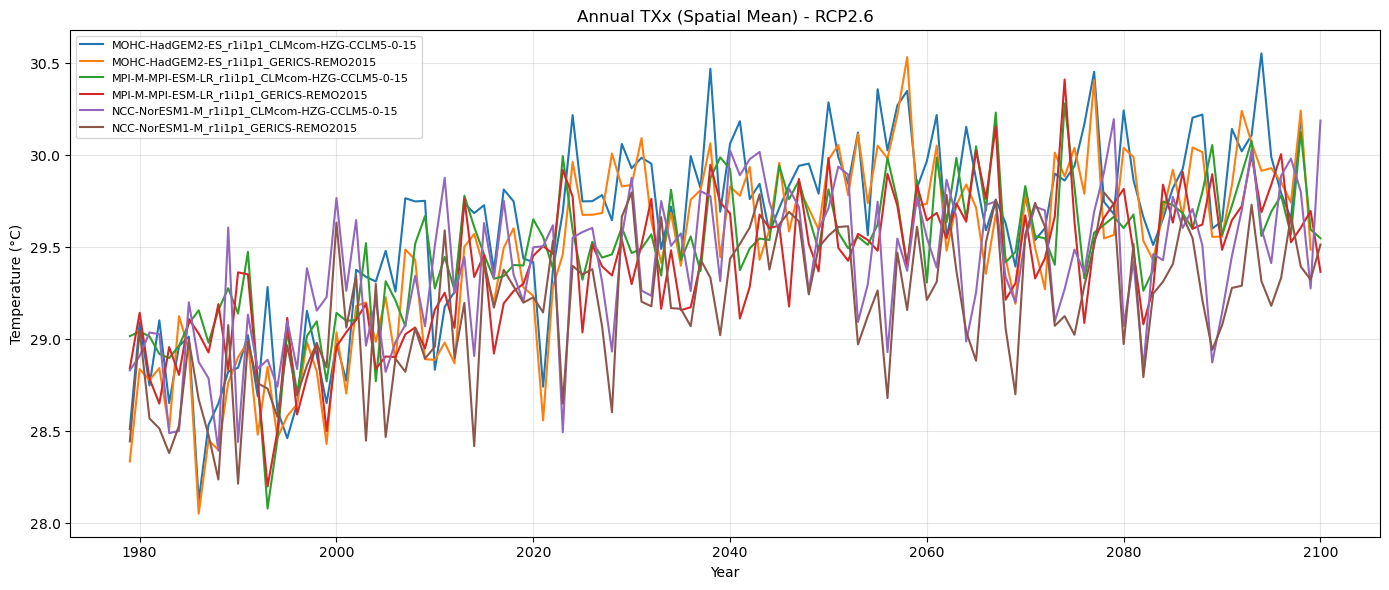

In [6]:
plot_annual_series(
    data_dir=OUTPUT_DIR / "TXx" / "rcp26",
    var="tasmax",
    title="Annual TXx (Spatial Mean) - RCP2.6",
    strip_from_label=[
        "TXx_VAN_sim-hist-fut_3km_BC_",
        "_v1_day_1979-2100_leaf-year_rcp26",
    ],
)

# Same plot function works for precipitation indices — just point it at the
# right folder/variable and adjust the y-axis label:
# plot_annual_series(
#     data_dir=OUTPUT_DIR / "rx1day" / "rcp26",
#     var="pr",
#     title="Annual RX1day (Spatial Mean) - RCP2.6",
#     ylabel="Precipitation (mm)",
# )
